In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.image import imread
%matplotlib inline

In [2]:
my_data_dir='../data/cell_images/'

In [3]:
os.listdir(my_data_dir) 

['.DS_Store', 'test', 'train']

In [4]:
test_path = my_data_dir+'/test/'
train_path = my_data_dir+'/train/'

In [5]:
os.listdir(test_path)

['.DS_Store', 'parasitized', 'uninfected']

In [6]:
os.listdir(train_path)

['.DS_Store', 'parasitized', 'uninfected']

In [7]:
os.listdir(train_path+'/parasitized')[0]

'C189P150ThinF_IMG_20151203_142224_cell_84.png'

In [8]:
para_cell = train_path+'/parasitized'+'/C100P61ThinF_IMG_20150918_144104_cell_162.png'

In [9]:
para_img= imread(para_cell)

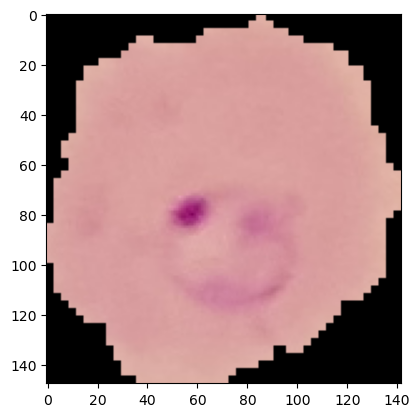

In [10]:
plt.imshow(para_img)

In [11]:
para_img.shape

(148, 142, 3)

In [12]:
len(os.listdir(train_path+'/parasitized'))

12480

In [13]:
len(os.listdir(train_path+'/uninfected'))

12480

In [14]:
dim1 = []
dim2 = []
for image_filename in os.listdir(test_path+'/uninfected'):
    
    img = imread(test_path+'/uninfected'+'/'+image_filename)
    d1,d2,colors = img.shape
    dim1.append(d1)
    dim2.append(d2)

In [15]:
np.mean(dim1)

130.92538461538462

In [16]:
np.mean(dim2)

130.75

In [17]:
image_shape = (130,130,3)

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [19]:
image_gen = ImageDataGenerator(rotation_range=20, # rotate the image 20 degrees
                               width_shift_range=0.10, # Shift the pic width by a max of 10%
                               height_shift_range=0.10, # Shift the pic height by a max of 10%
                               rescale=1/255, # Rescale the image by normalzing it.
                               shear_range=0.1, # Shear means cutting away part of the image (max 10%)
                               zoom_range=0.1, # Zoom in by 10% max
                               horizontal_flip=True, # Allo horizontal flipping
                               fill_mode='nearest' # Fill in missing pixels with the nearest filled value
                              )

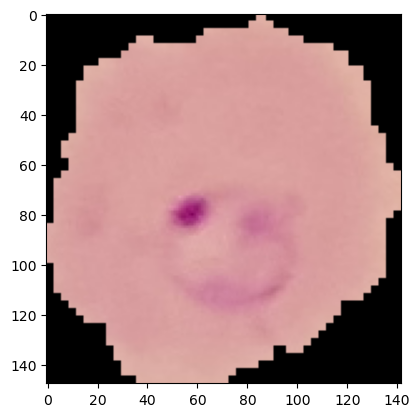

In [20]:
plt.imshow(para_img)

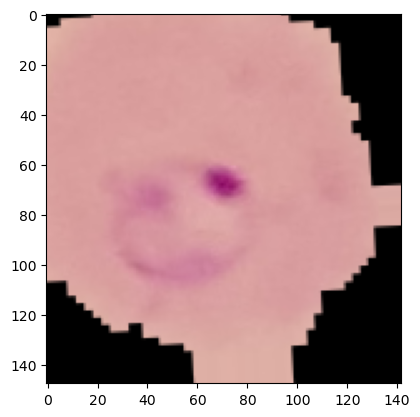

In [21]:
plt.imshow(image_gen.random_transform(para_img))

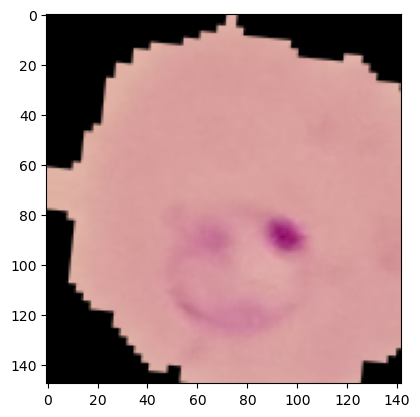

In [22]:
plt.imshow(image_gen.random_transform(para_img))

In [23]:
image_gen.flow_from_directory(train_path)

Found 24958 images belonging to 2 classes.


In [24]:
image_gen.flow_from_directory(test_path)

Found 2600 images belonging to 2 classes.


# Creating the Model

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Dropout, Flatten, Dense, Conv2D, MaxPooling2D

In [26]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3,3),input_shape=image_shape, activation='relu',))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3,3),input_shape=image_shape, activation='relu',))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3,3),input_shape=image_shape, activation='relu',))
model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Flatten())


model.add(Dense(128,activation='relu'))

# Dropouts help reduce overfitting by randomly turning neurons off during training.
# Here we say randomly turn off 50% of neurons.
model.add(Dropout(0.5))

# Last layer, remember its binary so we use sigmoid
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [27]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 62, 62, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 31, 31, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 29, 29, 64)        36928     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 64)        0

## Early Stopping

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

In [29]:
early_stop = EarlyStopping(monitor='val_loss',patience=2)

## Training the Model

In [30]:
batch_size = 16

In [31]:
train_image_gen = image_gen.flow_from_directory(train_path,
                                               target_size=image_shape[:2],
                                                color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary')

Found 24958 images belonging to 2 classes.


In [32]:
test_image_gen = image_gen.flow_from_directory(test_path,
                                               target_size=image_shape[:2],
                                               color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary',shuffle=False)

Found 2600 images belonging to 2 classes.


In [33]:
train_image_gen.class_indices

{'parasitized': 0, 'uninfected': 1}

In [34]:
import warnings
warnings.filterwarnings('ignore')

In [35]:
results = model.fit_generator(train_image_gen,epochs=20,
                              validation_data=test_image_gen,
                             callbacks=[early_stop])

Epoch 1/20
1560/1560 [==============================] - 107s 68ms/step - loss: 0.3809 - accuracy: 0.8335 - val_loss: 0.1938 - val_accuracy: 0.9281
Epoch 2/20
1560/1560 [==============================] - 107s 69ms/step - loss: 0.1844 - accuracy: 0.9427 - val_loss: 0.1776 - val_accuracy: 0.9404
Epoch 3/20
1560/1560 [==============================] - 107s 68ms/step - loss: 0.1694 - accuracy: 0.9487 - val_loss: 0.1542 - val_accuracy: 0.9469
Epoch 4/20
1560/1560 [==============================] - 108s 69ms/step - loss: 0.1608 - accuracy: 0.9504 - val_loss: 0.1713 - val_accuracy: 0.9381
Epoch 5/20
1560/1560 [==============================] - 108s 69ms/step - loss: 0.1612 - accuracy: 0.9488 - val_loss: 0.1686 - val_accuracy: 0.9481


In [36]:
from tensorflow.keras.models import load_model
model.save('malaria_detector.h5')

# Evaluating the Model

In [37]:
losses = pd.DataFrame(model.history.history)

<Axes: >

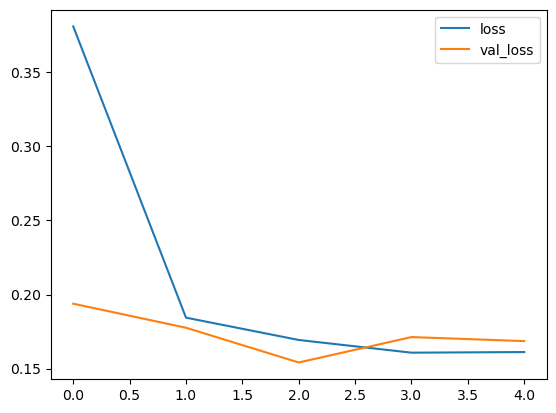

In [38]:
losses[['loss','val_loss']].plot()

In [39]:
model.metrics_names

['loss', 'accuracy']

In [40]:
model.evaluate_generator(test_image_gen)

[0.16547855734825134, 0.9449999928474426]

In [41]:
from tensorflow.keras.preprocessing import image

In [42]:
# https://datascience.stackexchange.com/questions/13894/how-to-get-predictions-with-predict-generator-on-streaming-test-data-in-keras
pred_probabilities = model.predict_generator(test_image_gen)

In [43]:
pred_probabilities

array([[1.9156882e-04],
       [1.3535834e-03],
       [6.6790526e-06],
       ...,
       [7.4969792e-01],
       [8.6451280e-01],
       [8.8092518e-01]], dtype=float32)

In [44]:
test_image_gen.classes

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [45]:
predictions = pred_probabilities > 0.5

In [46]:
# Numpy can treat this as True/False for us
predictions

array([[False],
       [False],
       [False],
       ...,
       [ True],
       [ True],
       [ True]])

In [47]:
from sklearn.metrics import classification_report,confusion_matrix

In [48]:
print(classification_report(test_image_gen.classes,predictions))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      1300
           1       0.93      0.96      0.95      1300

    accuracy                           0.95      2600
   macro avg       0.95      0.95      0.95      2600
weighted avg       0.95      0.95      0.95      2600



In [49]:
confusion_matrix(test_image_gen.classes,predictions)

array([[1213,   87],
       [  55, 1245]])

# Predicting on an Image

In [50]:
# Your file path will be different!
para_cell

'../data/cell_images//train//parasitized/C100P61ThinF_IMG_20150918_144104_cell_162.png'

In [51]:
my_image = image.load_img(para_cell,target_size=image_shape)

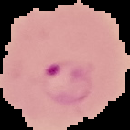

In [52]:
my_image

In [53]:
type(my_image)

PIL.Image.Image

In [54]:
my_image = image.img_to_array(my_image)

In [55]:
type(my_image)

numpy.ndarray

In [56]:
my_image.shape

(130, 130, 3)

In [57]:
my_image = np.expand_dims(my_image, axis=0)

In [58]:
my_image.shape

(1, 130, 130, 3)

In [59]:
model.predict(my_image)

1/1 [==============================] - 0s 33ms/step


array([[0.]], dtype=float32)

In [60]:
train_image_gen.class_indices

{'parasitized': 0, 'uninfected': 1}

In [61]:
test_image_gen.class_indices

{'parasitized': 0, 'uninfected': 1}